# DS-Wave non-adaptive testing

Standalone DS-Wave target solving and toroidal point synthesis.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # For Windows

import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


In [2]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np

import plotly.graph_objects as go
import nbformat
print(nbformat.__version__)
print(nbformat.__file__)

module_path = Path("ds-wave.py").resolve()
if not module_path.exists():
	module_path = Path("python") / "ds-wave.py"
module_path = module_path.resolve()
spec = importlib.util.spec_from_file_location("ds_wave", module_path)
ds_wave = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ds_wave)

python_dir = Path("python").resolve()
if python_dir.exists() and str(python_dir) not in sys.path:
	sys.path.insert(0, str(python_dir))
import ds_wave_3D as ds_wave_3d

plt.rcParams["figure.dpi"] = 120


def make_low_bands(max_nu):
	return [
		(low, min(high, max_nu))
		for (low, high) in [(0.0, 0.5), (0.5, 0.6), (0.6, 0.67), (0.67, max_nu)]
		if min(high, max_nu) > low
	]


def describe_target(label, target):
	print(f"{label}: status={target.status}, m0={target.m0}")
	if target.success:
		print(f"{label} r range: 0 <= r <= {target.r[-1]:.6f}, samples={len(target.r)}")
	else:
		print(target.message)


def print_target_mode_summary(label, target, max_nu, n_points, bands):
	print(f"\n{label}")
	if not target.success:
		print(target.message)
		return None
	report = ds_wave.compute_target_mode_powers(
		target,
		n_points=n_points,
		nu_max=max_nu,
		mode_limit=0,
	)
	print_mode_report(report, bands)
	return report


def print_mode_report(report, bands=None, top_count=0):
	print(f"mode count: {report['mode_count']}")
	print(f"mean power:   {report['mean_power']:.10f}")
	print(f"median power: {report['median_power']:.10f}")
	print(f"max power:    {report['max_power']:.10f}")
	if bands is not None:
		for summary in ds_wave.summarise_mode_power_bands(report, bands):
			(lo, hi) = summary["range"]
			print(
				f"{lo:.3f} <= nu < {hi:.3f}: "
				f"count={summary['count']}, "
				f"mean={summary['mean_power']:.10f}, "
				f"median={summary['median_power']:.10f}, "
				f"max={summary['max_power']:.10f}"
			)
	if top_count > 0:
		print("Top low-frequency modes:")
		for (mode, radius, power) in zip(report["modes"][:top_count], report["radii"][:top_count], report["powers"][:top_count]):
			print(f"k={mode.astype(int)}, nu={radius:.6f}, power={power:.6f}")


def print_point_mode_summary(label, point_set, max_nu, bands=None, mode_limit=0, top_count=0):
	print(f"\n{label}")
	report = ds_wave.compute_low_frequency_mode_powers(
		point_set,
		nu_max=max_nu,
		mode_limit=mode_limit,
	)
	print_mode_report(report, bands=bands, top_count=top_count)
	return report


def set_active_points(point_set, label):
	global points, active_points_label
	points = point_set
	active_points_label = label
	print(f"Active point set: {active_points_label}")

5.10.4
c:\Users\admin\miniconda3\envs\bluenoise_pointprocesses\lib\site-packages\nbformat\__init__.py


In [ ]:
# Easy-to-edit parameters
nu0 = 0.85
#nu0 = 0.70
e0 = 0.0
nu_max = 5.0
n_nu = 1001
n_r = 128

# while traveling, use fewer points cause laptop is shit
n_points = 1024
iterations = 500
seed = 1234
m0_values = [1.0, 2.0, "min"]
device = "auto"

# PCF matching is the only synthesis algorithm: the faithful Heck-2013 / DS-Wave
# RDF-matching optimizer that produces the decaying-square-wave radial PSD.
step_scale = 1.0
num_bins = None  # None resolves to max(4096, n_points): RDF bins decoupled from N
smoothing = None
chunk_size = 256
initial_points = None

# Effective PCF resolution implied by the (None, None) defaults above.
from ds_wave_targetrdf import resolve_targetrdf_resolution
(resolved_num_bins, resolved_smoothing) = resolve_targetrdf_resolution(n_points, num_bins, smoothing)
print(f"resolved PCF resolution: nbins={resolved_num_bins}, smoothing={resolved_smoothing:.2f} bins")

# Extra tests
sweep_iterations = min(iterations, 1000)
sweep_include_full_domain_target = True
sweep_smoothing_values = [0.5 * resolved_smoothing, resolved_smoothing, 1.5 * resolved_smoothing]
sweep_num_bins_values = [128, 256, 512]
sweep_step_scale_values = [0.5 * step_scale, step_scale, 1.5 * step_scale]

n_points_3d = 4096
iterations_3d = 5 * iterations
num_bins_3d = None  # None resolves to max(4096, n_points): RDF bins decoupled from N (RC-1 fix, 3D)
smoothing_3d = None  # None holds the calibrated normalized sigma_rnorm=0.04 via the N^(1/3) normalizer
step_scale_3d = step_scale
chunk_size_3d = chunk_size


resolved PCF resolution: nbins=4096, smoothing=10.24 bins


m0=1.0: infeasible - The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
m0=2.0: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)
m0=min: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)


C:\Users\admin\AppData\Local\Temp\ipykernel_32376\4275589289.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


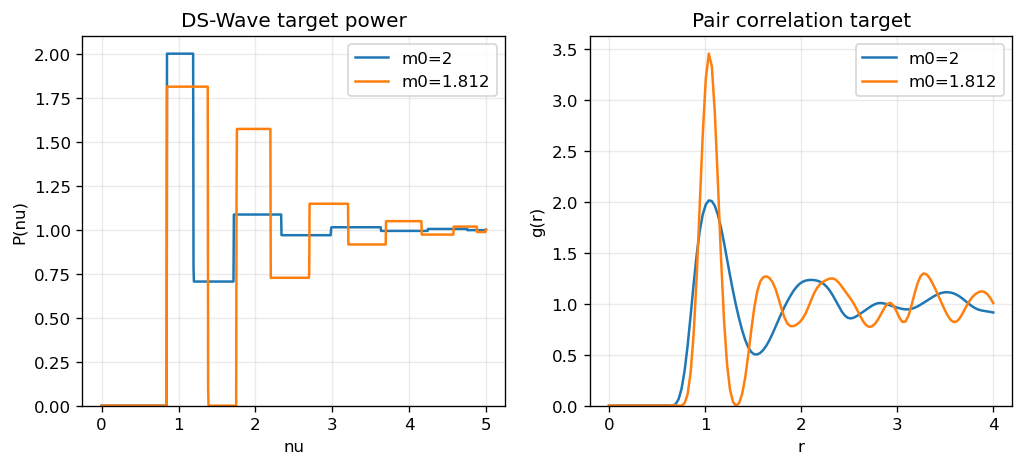

In [4]:
targets = {}
for requested in m0_values:
	if requested == "min":
		m0 = ds_wave.find_min_m0(nu0=nu0, e0=e0, nu_max=nu_max, n_nu=n_nu, n_r=n_r)
		if m0 is None:
			print("m0=min: infeasible - no feasible finite m0 found.")
			continue
	else:
		m0 = requested
	target = ds_wave.solve_ds_wave_target(
		nu0=nu0,
		e0=e0,
		m0=m0,
		nu_max=nu_max,
		n_nu=n_nu,
		n_r=n_r,
	)
	target.requested_m0 = str(requested)
	targets[str(requested)] = target
	print(f"m0={requested}: {target.status} - {target.message}")

fig = ds_wave.plot_ds_wave_targets(list(targets.values()))
fig.show()


In [5]:
# Compare the default r_max target against a target solved over the full
# TargetRDF distance domain: unit-square distances up to 0.5 correspond to
# normalized r up to 0.5 * sqrt(N) (~32 samples per unit r).
min_target = targets["min"]
full_r_max = 0.5 * np.sqrt(float(n_points))
full_n_r = max(2, int(np.ceil(32.0 * full_r_max)))
full_domain_target = ds_wave.solve_ds_wave_target(
	nu0=nu0,
	e0=e0,
	m0=min_target.m0,
	nu_max=nu_max,
	n_nu=n_nu,
	r_max=full_r_max,
	n_r=full_n_r,
)
full_domain_target.requested_m0 = "min"

target_low_bands = make_low_bands(nu0)
for (label, target) in [("current target", min_target), ("full-domain target", full_domain_target)]:
	describe_target(label, target)

for (label, target) in [("current r_max target", min_target), ("full TargetRDF-domain target", full_domain_target)]:
	print_target_mode_summary(label, target, nu0, n_points, target_low_bands)


current target: status=optimal, m0=1.8125
current target r range: 0 <= r <= 4.000000, samples=128
full-domain target: status=optimal, m0=1.8125
full-domain target r range: 0 <= r <= 16.000000, samples=512

current r_max target
mode count: 2320
mean power:   0.0000000000
median power: 0.0000000000
max power:    0.0000000000
0.000 <= nu < 0.500: count=792, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.500 <= nu < 0.600: count=360, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.600 <= nu < 0.670: count=296, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.670 <= nu < 0.850: count=872, mean=0.0000000000, median=0.0000000000, max=0.0000000000

full TargetRDF-domain target
mode count: 2320
mean power:   0.0000000000
median power: 0.0000000000
max power:    0.0000000000
0.000 <= nu < 0.500: count=792, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.500 <= nu < 0.600: count=360, mean=0.0000000000, median=0.0000000000, max=0.0000000000
0.600 <= nu <

In [6]:
min_target = targets["min"]
if not min_target.success:
	raise RuntimeError(min_target.message)

raw_synthesis = ds_wave.synthesize_targetrdf_points(
	min_target,
	n_points=n_points,
	iterations=iterations,
	seed=seed,
	device=device,
	step_scale=step_scale,
	nbins=num_bins,
	smoothing=smoothing,
	chunk_size=chunk_size,
	initial_points=initial_points,
	log_every=100,
)
raw_points = raw_synthesis.points
set_active_points(raw_points, "raw PCF points")
print(f"device={raw_synthesis.device}, final energy={raw_synthesis.energy_history[-1]:.6g}")
print(raw_points.shape, raw_points.min(), raw_points.max())
print(f"iterations run: {raw_synthesis.iterations_run}, energies logged: {len(raw_synthesis.energy_history)}")
print("Energy history (last 10):")
for value in raw_synthesis.energy_history[-10:]:
	print(value)


Active point set: raw PCF points
device=cuda, final energy=0.0270986
(1024, 2) 0.0013696811 0.9994219
iterations run: 500, energies logged: 6
Energy history (last 10):
0.18659
0.03991088
0.028471014
0.027343197
0.027098557
0.027098557


In [7]:
# PCF synthesis comparison for the full TargetRDF-domain target.
if not full_domain_target.success:
	raise RuntimeError(full_domain_target.message)

full_domain_synthesis = ds_wave.synthesize_targetrdf_points(
	full_domain_target,
	n_points=n_points,
	iterations=iterations,
	seed=seed,
	device=device,
	step_scale=step_scale,
	nbins=num_bins,
	smoothing=smoothing,
	chunk_size=chunk_size,
	initial_points=initial_points,
	log_every=100,
)
full_domain_points = full_domain_synthesis.points
print(
	f"device={full_domain_synthesis.device}, "
	f"final energy={full_domain_synthesis.energy_history[-1]:.6g}"
)
print(full_domain_points.shape, full_domain_points.min(), full_domain_points.max())

comparison_low_bands = make_low_bands(nu0)
comparison_sets = [
	("raw TargetRDF points", raw_points),
	("active plotted points", points),
	("full TargetRDF-domain points", full_domain_points),
]

seen = set()
for (label, compare_points) in comparison_sets:
	object_id = id(compare_points)
	if object_id in seen:
		print(f"\n{label}: same array as an earlier row; skipped duplicate.")
		continue
	seen.add(object_id)
	print_point_mode_summary(label, compare_points, nu0, bands=comparison_low_bands)


device=cuda, final energy=0.0273877
(1024, 2) 0.00027627742 0.99984014

raw TargetRDF points
mode count: 2320
mean power:   0.0787526891
median power: 0.0366017409
max power:    3.1651067734
0.000 <= nu < 0.500: count=792, mean=0.0269753952, median=0.0162285026, max=0.2134524286
0.500 <= nu < 0.600: count=360, mean=0.0531232692, median=0.0348589383, max=0.3180824220
0.600 <= nu < 0.670: count=296, mean=0.0651999712, median=0.0520326942, max=0.2579874992
0.670 <= nu < 0.850: count=872, mean=0.1409611851, median=0.0694111586, max=3.1651067734

active plotted points: same array as an earlier row; skipped duplicate.

full TargetRDF-domain points
mode count: 2320
mean power:   0.0720656961
median power: 0.0348533168
max power:    1.9917341471
0.000 <= nu < 0.500: count=792, mean=0.0269739870, median=0.0175535269, max=0.3702130914
0.500 <= nu < 0.600: count=360, mean=0.0542288087, median=0.0376100168, max=0.2940301895
0.600 <= nu < 0.670: count=296, mean=0.0620750040, median=0.0421353728, ma

C:\Users\admin\AppData\Local\Temp\ipykernel_32376\863102607.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


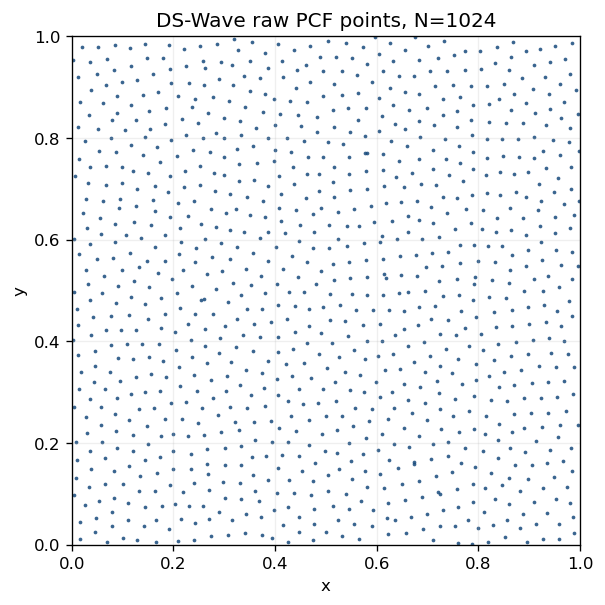

In [8]:
fig = ds_wave.plot_points(points, title=f"DS-Wave {active_points_label}, N={points.shape[0]}")
fig.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_32376\2259755339.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


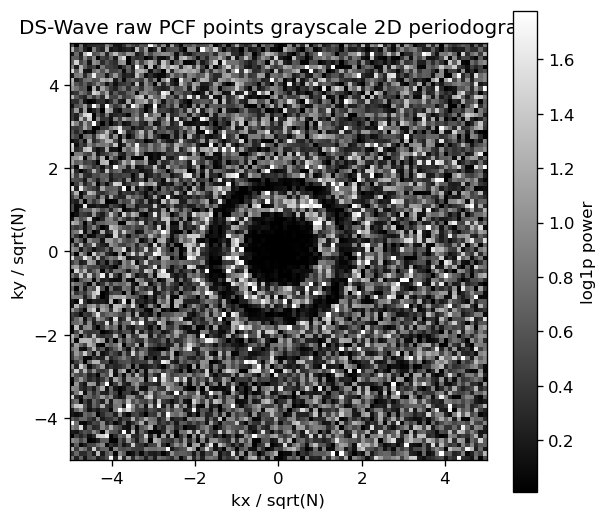

In [9]:
power_2d, extent = ds_wave.compute_periodogram_2d(points, grid_size=96, max_freq=nu_max)
fig = ds_wave.plot_periodogram(power_2d, extent, title=f"DS-Wave {active_points_label} grayscale 2D periodogram")
fig.show()


active point set: raw PCF points
low-frequency grid: k_max=48, grid_size=97


C:\Users\admin\AppData\Local\Temp\ipykernel_32376\842693837.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


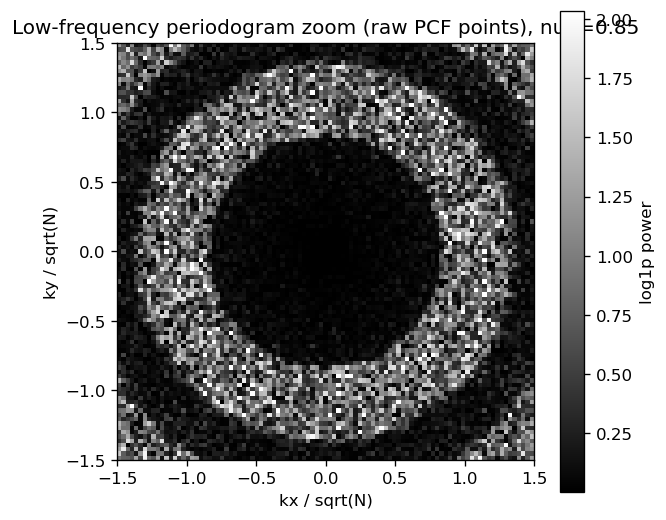

In [10]:
# Low-frequency periodogram zoom for the forbidden disk.
# This uses a contiguous integer-mode grid instead of the sparse wide-range display.
low_periodogram_max_freq = max(1.5, 1.5 * nu0)
low_k_max = int(np.ceil(low_periodogram_max_freq * np.sqrt(float(points.shape[0]))))
low_grid_size = 2 * low_k_max + 1
print(f"active point set: {active_points_label}")
print(f"low-frequency grid: k_max={low_k_max}, grid_size={low_grid_size}")

low_power_2d, low_extent = ds_wave.compute_periodogram_2d(
	points,
	grid_size=low_grid_size,
	max_freq=low_periodogram_max_freq,
)
fig = ds_wave.plot_periodogram(
	low_power_2d,
	low_extent,
	title=f"Low-frequency periodogram zoom ({active_points_label}), nu0={nu0}",
)
fig.show()


active point set: raw PCF points

active point set low-frequency powers
mode count: 2320
mean power:   0.0787526891
median power: 0.0366017409
max power:    3.1651067734
0.000 <= nu < 0.500: count=792, mean=0.0269753952, median=0.0162285026, max=0.2134524286
0.500 <= nu < 0.600: count=360, mean=0.0531232692, median=0.0348589383, max=0.3180824220
0.600 <= nu < 0.670: count=296, mean=0.0651999712, median=0.0520326942, max=0.2579874992
0.670 <= nu < 0.850: count=872, mean=0.1409611851, median=0.0694111586, max=3.1651067734
Top low-frequency modes:
k=[  2 -27], nu=0.846062, power=3.165107
k=[-2 27], nu=0.846062, power=3.165107
k=[ -3 -27], nu=0.848942, power=2.735371
k=[ 3 27], nu=0.848942, power=2.735371
k=[-3 27], nu=0.848942, power=2.502218
k=[  3 -27], nu=0.848942, power=2.502218
k=[ -2 -27], nu=0.846062, power=2.280456
k=[ 2 27], nu=0.846062, power=2.280456
k=[-21 -17], nu=0.844329, power=1.717357
k=[21 17], nu=0.844329, power=1.717357
k=[27 -1], nu=0.844329, power=1.285462
k=[-27   1

C:\Users\admin\AppData\Local\Temp\ipykernel_32376\3033107872.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


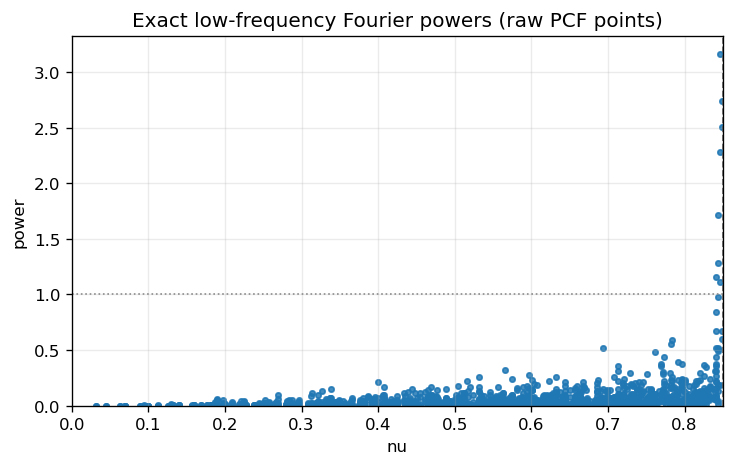

In [11]:
# Exact low-frequency mode report for nu < nu0.
print(f"active point set: {active_points_label}")
low_bands = make_low_bands(nu0)
low_report = print_point_mode_summary(
	"active point set low-frequency powers",
	points,
	nu0,
	bands=low_bands,
	top_count=20,
)

fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.scatter(low_report["radii"], low_report["powers"], s=10, alpha=0.6)
ax.axvline(nu0, color="0.4", linestyle="--", linewidth=1)
ax.axhline(1.0, color="0.55", linestyle=":", linewidth=1)
ax.set_title(f"Exact low-frequency Fourier powers ({active_points_label})")
ax.set_xlabel("nu")
ax.set_ylabel("power")
ax.set_xlim(0.0, nu0)
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.25)
fig.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_32376\2902279785.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


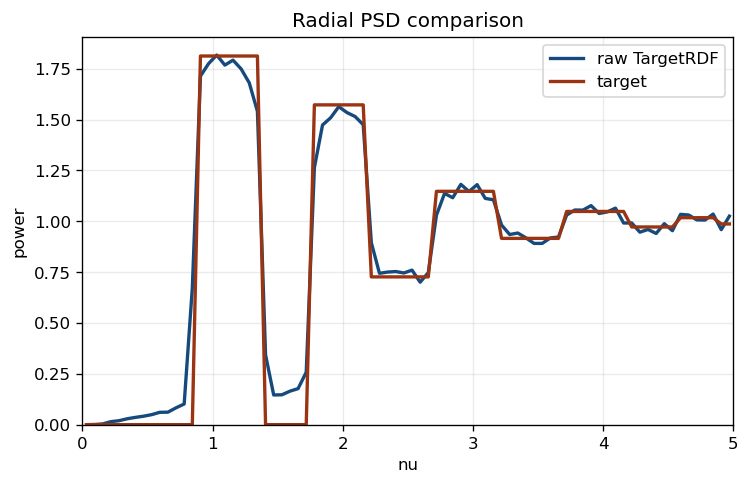

In [12]:
# Radial PSD of the raw TargetRDF result vs the decaying-square-wave target.
(freqs, raw_radial) = ds_wave.compute_radial_psd(
	raw_points,
	num_bins=80,
	max_freq=nu_max,
	mode_limit=0,
	priority_nu=min_target.nu0,
)
target_power = ds_wave.interpolate_target_power(min_target, freqs)
(fig, ax) = plt.subplots(figsize=(7.0, 4.2), dpi=120)
ax.plot(freqs, raw_radial, label="raw TargetRDF", color="#174a7c", linewidth=2.0)
ax.plot(freqs, target_power, label="target", color="#9a3412", linewidth=2.0)
ax.set_title("Radial PSD comparison")
ax.set_xlabel("nu")
ax.set_ylabel("power")
ax.set_xlim(0.0, nu_max)
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.25)
ax.legend()
fig.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_32376\242641461.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


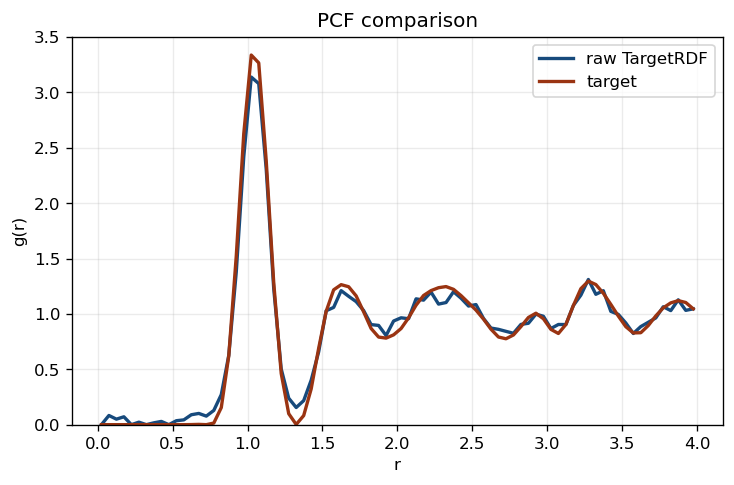

In [13]:
# PCF of the raw TargetRDF result vs the target g(r).
(fig, ax) = plt.subplots(figsize=(7.0, 4.2), dpi=120)
(r, empirical) = ds_wave.compute_empirical_pcf(raw_points, r_max=float(min_target.r[-1]))
ax.plot(r, empirical, label="raw TargetRDF", color="#174a7c", linewidth=2.0)
target_g = ds_wave.interpolate_target_pcf(min_target, r)
ax.plot(r, target_g, label="target", color="#9a3412", linewidth=2.0)
ax.set_title("PCF comparison")
ax.set_xlabel("r")
ax.set_ylabel("g(r)")
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.25)
ax.legend()
fig.show()


## Ensemble radial-PSD verification

A single realization's periodogram is noisy, so the radial PSD above can look ragged even when the
underlying point process is correct.
This will average the radial PSD is over several independently
seeded syntheses and compared against the target binned over the same Fourier modes. 
A localized-peak detector then checks the original failure mode: interior local maxima exceeding the target by more than +0.3.

In [14]:
import ds_wave_psd_eval as psd_eval

ens_n_points = 4096
ens_seeds = list(range(1, 9))
ens_iterations = 400
ens_num_bins = 96
ens_max_freq = 5.0
ens_mode_limit = 24000

ens_freqs, ens_psd, ens_binned_target = psd_eval.ensemble_radial_psd(
	min_target,
	n_points=ens_n_points,
	seeds=ens_seeds,
	iterations=ens_iterations,
	device=device,
	max_freq=ens_max_freq,
	num_bins=ens_num_bins,
	mode_limit=ens_mode_limit,
	return_binned_target=True,
)

ens_metrics = psd_eval.psd_fit_metrics(ens_freqs, ens_psd, min_target, target_power=ens_binned_target)
print(f"rmse                      = {ens_metrics['rmse']:.4f}   (acceptance gate < 0.15 at N=4096)")
print(f"max_abs_residual          = {ens_metrics['max_abs_residual']:.4f}   (reported only: edge bins of the discontinuous target)")
print(f"max_abs_residual_interior = {ens_metrics['max_abs_residual_interior']:.4f}   (gate < 0.40)")
print(f"low_band_mean_power       = {ens_metrics['low_band_mean_power']:.4f}   (gate < 0.10)")

ens_disc = psd_eval.find_target_discontinuities(min_target)
ens_residual = ens_psd - ens_binned_target
ens_bin_width = ens_freqs[1] - ens_freqs[0]
ens_interior = np.array([np.all(np.abs(f - ens_disc) > ens_bin_width) for f in ens_freqs])
ens_peaks = [
	(float(ens_freqs[i]), float(ens_psd[i]), float(ens_binned_target[i]), float(ens_residual[i]))
	for i in range(1, len(ens_freqs) - 1)
	if ens_interior[i] and ens_residual[i] > 0.3
	and ens_residual[i] >= ens_residual[i - 1] and ens_residual[i] >= ens_residual[i + 1]
]
if ens_peaks:
	print("\nLOCALIZED PEAKS DETECTED (nu, empirical, target, residual):")
	for peak in ens_peaks:
		print(f"  nu={peak[0]:.3f}: {peak[1]:.3f} vs {peak[2]:.3f} (+{peak[3]:.3f})")
else:
	print("\nNo localized interior peaks (residual > +0.3): the PSD tracks the decaying square wave.")


rmse                      = 0.0769   (acceptance gate < 0.15 at N=4096)
max_abs_residual          = 0.2636   (reported only: edge bins of the discontinuous target)
max_abs_residual_interior = 0.2462   (gate < 0.40)
low_band_mean_power       = 0.0266   (gate < 0.10)

No localized interior peaks (residual > +0.3): the PSD tracks the decaying square wave.


C:\Users\admin\AppData\Local\Temp\ipykernel_32376\581626931.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


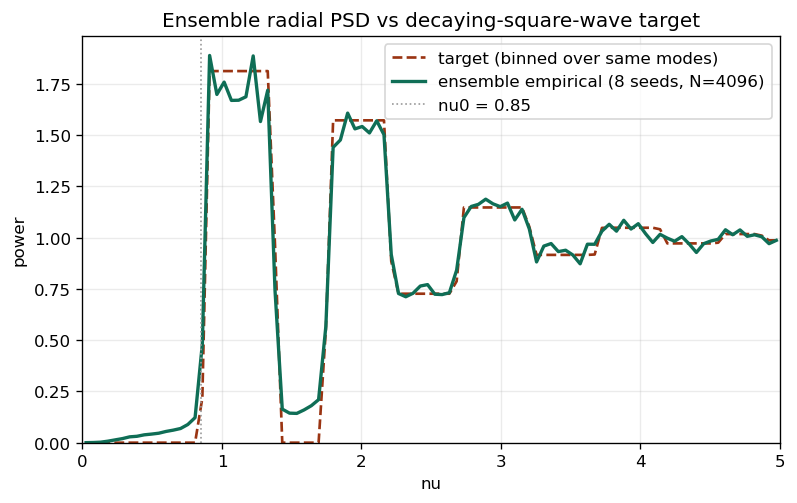

In [15]:
# Overlay: ensemble empirical radial PSD vs the decaying-square-wave target.
(fig, ax) = plt.subplots(figsize=(7.5, 4.4), dpi=120)
ax.plot(
	ens_freqs,
	ens_binned_target,
	label="target (binned over same modes)",
	color="#9a3412",
	linewidth=1.6,
	linestyle="--",
)
ax.plot(
	ens_freqs,
	ens_psd,
	label=f"ensemble empirical ({len(ens_seeds)} seeds, N={ens_n_points})",
	color="#0F6E56",
	linewidth=2.0,
)
ax.axvline(min_target.nu0, color="0.6", linestyle=":", linewidth=1, label=f"nu0 = {min_target.nu0}")
for peak in ens_peaks:
	ax.annotate(
		f"peak +{peak[3]:.2f}",
		xy=(peak[0], peak[1]),
		xytext=(peak[0], peak[1] + 0.25),
		arrowprops=dict(arrowstyle="->", color="#A32D2D"),
		color="#A32D2D",
		fontsize=9,
		ha="center",
	)
ax.set_title("Ensemble radial PSD vs decaying-square-wave target")
ax.set_xlabel("nu")
ax.set_ylabel("power")
ax.set_xlim(0.0, ens_max_freq)
ax.set_ylim(bottom=0.0)
ax.grid(True, alpha=0.25)
ax.legend()
fig.show()


In [16]:
parameter_sweep_results = []
sweep_targets = [("current target", min_target)]
if sweep_include_full_domain_target:
	sweep_targets.append(("full-domain target", full_domain_target))

sweep_low_bands = make_low_bands(nu0)


def run_one_sweep(target_name, target, parameter_name, parameter_value, sweep_step_scale, sweep_num_bins, sweep_smoothing):
	print(f"Running sweep: target={target_name}, {parameter_name}={parameter_value}")
	sweep_result = ds_wave.synthesize_targetrdf_points(
		target,
		n_points=n_points,
		iterations=sweep_iterations,
		seed=seed,
		device=device,
		step_scale=sweep_step_scale,
		nbins=sweep_num_bins,
		smoothing=sweep_smoothing,
		chunk_size=chunk_size,
		initial_points=initial_points,
		log_every=sweep_iterations,
	)
	sweep_report = ds_wave.compute_low_frequency_mode_powers(
		sweep_result.points,
		nu_max=nu0,
		mode_limit=0,
	)
	parameter_sweep_results.append({
		"target_name": target_name,
		"parameter_name": parameter_name,
		"parameter_value": parameter_value,
		"final_energy": float(sweep_result.energy_history[-1]),
		"mean_power": sweep_report["mean_power"],
		"median_power": sweep_report["median_power"],
		"max_power": sweep_report["max_power"],
		"band_summaries": ds_wave.summarise_mode_power_bands(sweep_report, sweep_low_bands),
		"iterations_run": sweep_result.iterations_run,
	})
	print_mode_report(sweep_report, bands=sweep_low_bands)


for (target_name, target) in sweep_targets:
	if not target.success:
		print(f"Skipping {target_name}: target did not solve successfully.")
		continue
	for value in sweep_smoothing_values:
		run_one_sweep(target_name, target, "smoothing", value, step_scale, num_bins, value)
	for value in sweep_num_bins_values:
		run_one_sweep(target_name, target, "num_bins", value, step_scale, value, smoothing)
	for value in sweep_step_scale_values:
		run_one_sweep(target_name, target, "step_scale", value, value, num_bins, smoothing)

print(f"sweep results: {len(parameter_sweep_results)} runs")


Running sweep: target=current target, smoothing=5.12
mode count: 2320
mean power:   0.0820575505
median power: 0.0359142125
max power:    4.9908790588
0.000 <= nu < 0.500: count=792, mean=0.0275012944, median=0.0161559619, max=0.2375059426
0.500 <= nu < 0.600: count=360, mean=0.0574884824, median=0.0395002142, max=0.3945782781
0.600 <= nu < 0.670: count=296, mean=0.0600434504, median=0.0412197597, max=0.3942686319
0.670 <= nu < 0.850: count=872, mean=0.1492245048, median=0.0739767551, max=4.9908790588
Running sweep: target=current target, smoothing=10.24
mode count: 2320
mean power:   0.0787526891
median power: 0.0366017409
max power:    3.1651067734
0.000 <= nu < 0.500: count=792, mean=0.0269753952, median=0.0162285026, max=0.2134524286
0.500 <= nu < 0.600: count=360, mean=0.0531232692, median=0.0348589383, max=0.3180824220
0.600 <= nu < 0.670: count=296, mean=0.0651999712, median=0.0520326942, max=0.2579874992
0.670 <= nu < 0.850: count=872, mean=0.1409611851, median=0.0694111586, ma

3D m0=1.34375: optimal - Optimization terminated successfully. (HiGHS Status 7: Optimal)


C:\Users\admin\AppData\Local\Temp\ipykernel_32376\2767334434.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


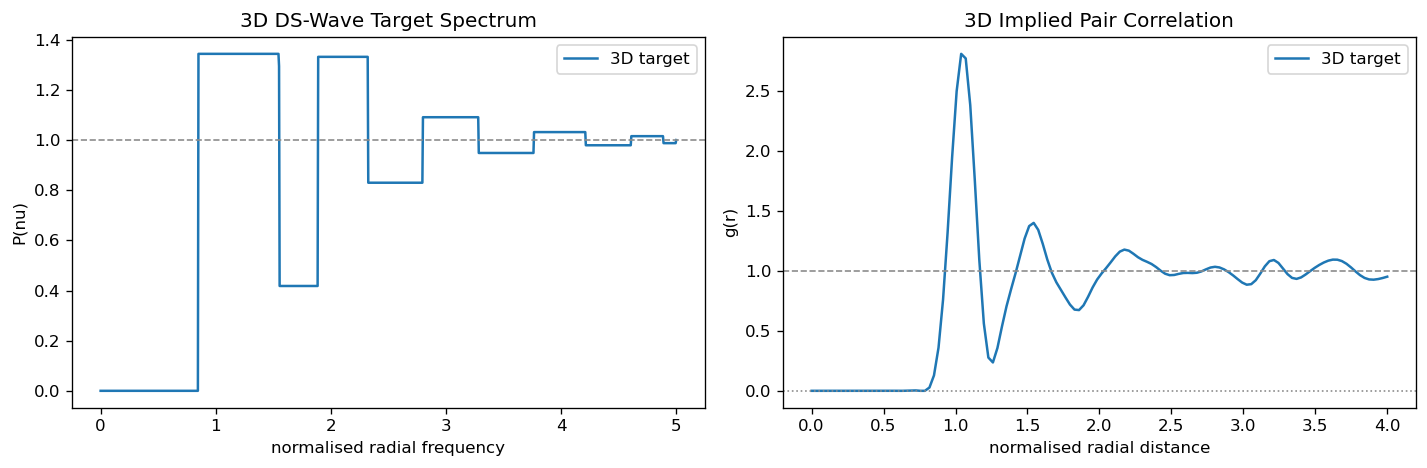

3D points: (4096, 3), device=cuda
Energy history:
0.19742581
0.008572191
0.0075658415
0.0072545344
0.0071611777
0.0071504666
0.007149765
0.007149765
0.007149765
0.007149765
0.007149765


C:\Users\admin\AppData\Local\Temp\ipykernel_32376\241240304.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\admin\AppData\Local\Temp\ipykernel_32376\241240304.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


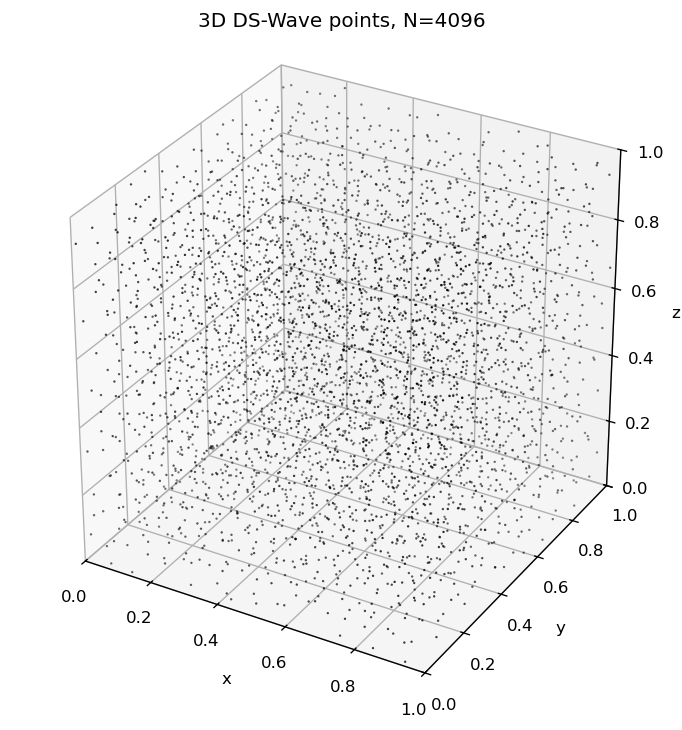

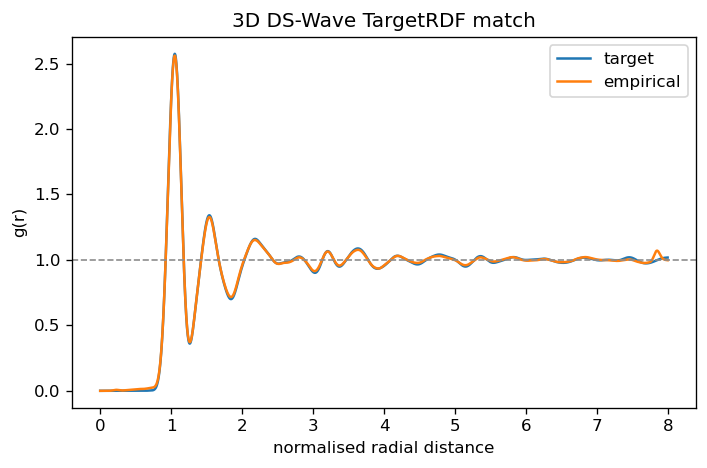

C:\Users\admin\AppData\Local\Temp\ipykernel_32376\337161806.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


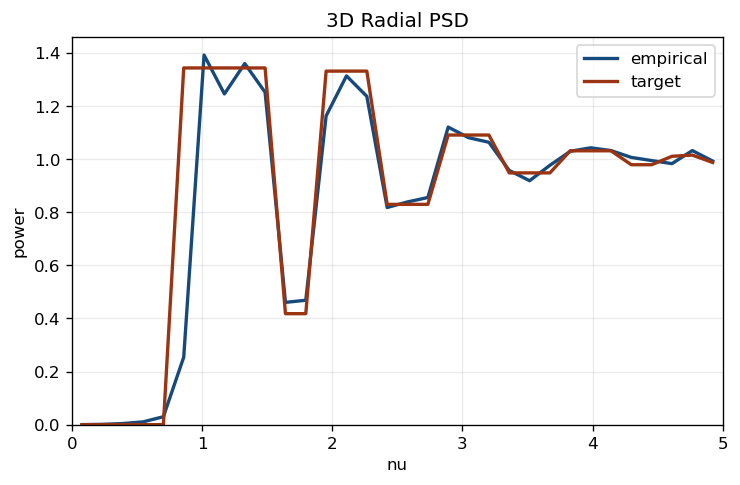

C:\Users\admin\AppData\Local\Temp\ipykernel_32376\2810252464.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


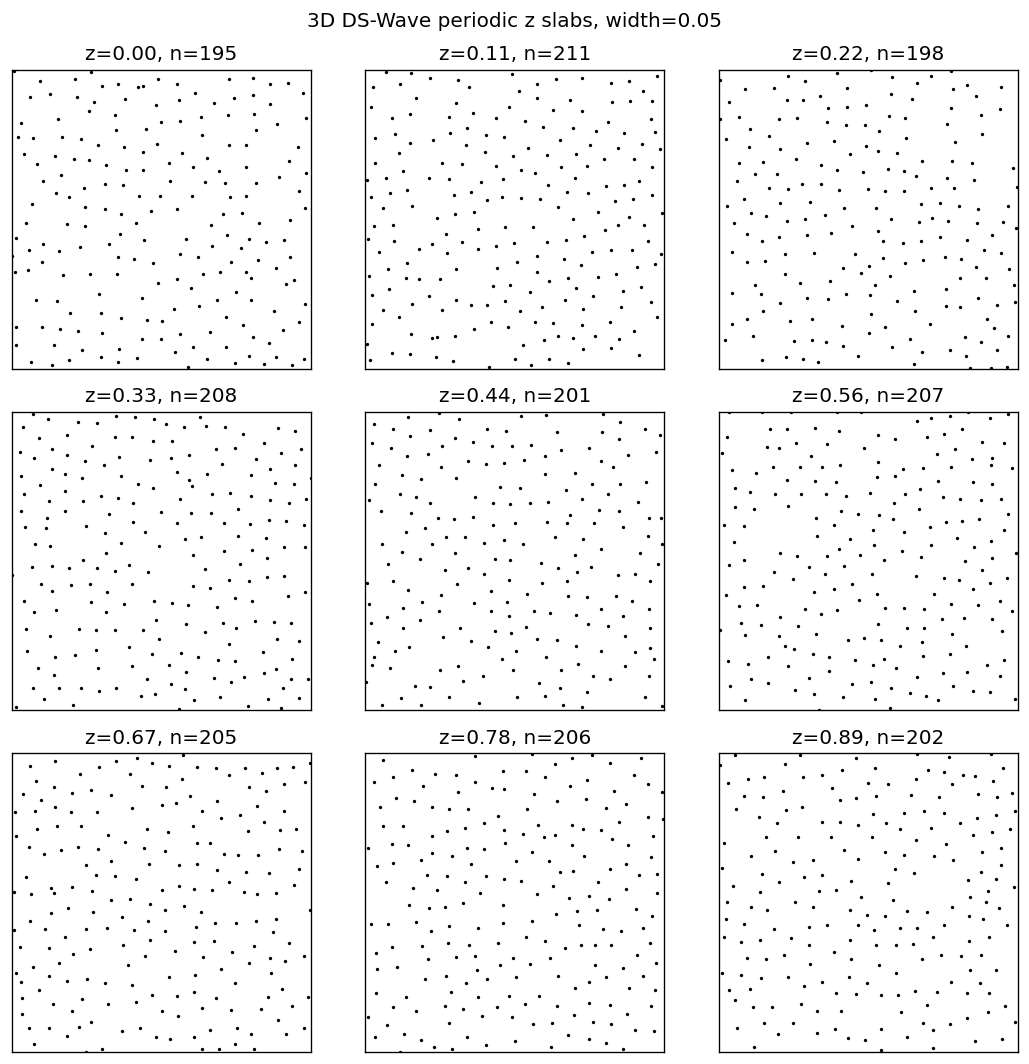

slice points: 200 / 4096


C:\Users\admin\AppData\Local\Temp\ipykernel_32376\1425157432.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


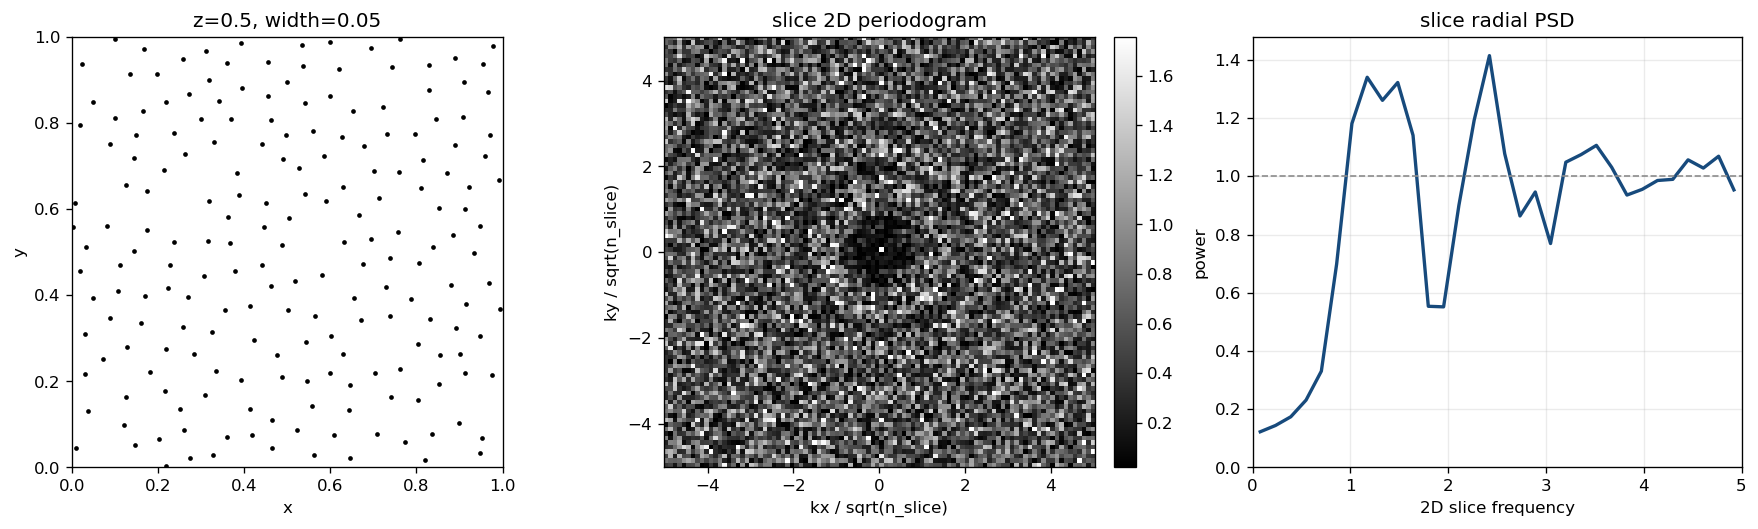